# Travelling Salesman Problem

In [1]:
# !pip install qiskit qiskit-optimization
# !pip install networkx matplotlib

# 🔹 Step 2: Define cities and distances

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Cities
cities = ["M", "S", "B", "C"]
N = len(cities)

# Distances
W = {
    ("M","S"):250, ("S","B"):200, ("B","C"):300, ("C","M"):450,
    ("S","M"):250, ("B","S"):200, ("C","B"):300, ("M","C"):450,
}

G = nx.DiGraph()

# Add nodes
G.add_nodes_from(cities)

# Add edges with weights
for (u, v), w in W.items():
    G.add_edge(u, v, weight=w)

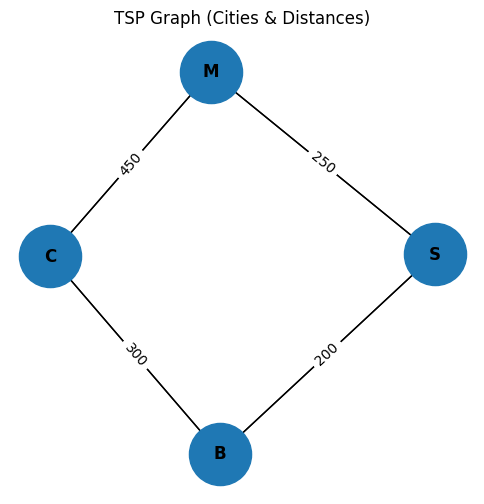

In [3]:
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(6,6))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2000)

# Draw edges
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)

# Labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Edge weights
edge_labels = {(u,v): w for (u,v), w in W.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("TSP Graph (Cities & Distances)")
plt.axis('off')
plt.show()

# 🔹 Step 3: Create variables


In [4]:
from qiskit_optimization import QuadraticProgram

qp = QuadraticProgram()

x = {}
for v in cities:
    for j in range(N):
        x[(v,j)] = qp.binary_var(name=f"x_{v}_{j}")

# 🔹 Step 4: Build Hamiltonian (QUBO)

In [5]:
#parameters
A = 10   # large penalty
B = 1      # distance weight

# ✅ Constraint 1: Each city once

In [6]:
for v in cities:
    qp.linear_constraint(
        linear={f"x_{v}_{j}": 1 for j in range(N)},
        sense='==',
        rhs=1,
        name=f"visit_{v}"
    )

# ✅ Constraint 2: Each position exactly one city

In [7]:
for j in range(N):
    qp.linear_constraint(
        linear={f"x_{v}_{j}": 1 for v in cities},
        sense='==',
        rhs=1,
        name=f"pos_{j}"
    )

# ✅ Constraint 3 + Distance

We combine valid edges + weights:

In [8]:
linear = {}
quadratic = {}

for j in range(N):
    next_j = (j + 1) % N
    
    for u in cities:
        for v in cities:
            if u != v and (u, v) in W:
                key = (f"x_{u}_{j}", f"x_{v}_{next_j}")
                quadratic[key] = W[(u, v)]

# Set objective

In [9]:
qp.minimize(linear=linear, quadratic=quadratic)

# Convert to QUBO

In [10]:
from qiskit_optimization.converters import QuadraticProgramToQubo

A = 10  # penalty weight
converter = QuadraticProgramToQubo(penalty=A)

qubo = converter.convert(qp)

# Solve
Option A: Classical solver

In [11]:
# from qiskit_optimization.algorithms import MinimumEigenOptimizer
# from qiskit_algorithms import NumPyMinimumEigensolver

# solver = MinimumEigenOptimizer(NumPyMinimumEigensolver())
# result = solver.solve(qubo)

# print(result)

In [12]:
# route = [None]*4

# for (v,j), var in x.items():
#     if result.x[qubo.variables_index[var.name]] == 1:
#         route[j] = v

# print("Route:", route)

In [13]:
# path = route + [route[0]]  # close cycle
# path_edges = list(zip(path[:-1], path[1:]))

# Statevector sampler took more than an hr and still didnt return result 

In [20]:
from qiskit_algorithms import QAOA
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer

sampler = StatevectorSampler()
optimizer = COBYLA(maxiter=2)

qaoa = QAOA(sampler=sampler, optimizer=optimizer, reps=1)

solver = MinimumEigenOptimizer(qaoa)
result = solver.solve(qubo)

print(result)

e:\Hobby\30DayChallenge\qiskit_env\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
e:\Hobby\30DayChallenge\qiskit_env\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
e:\Hobby\30DayChallenge\qiskit_env\lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


MemoryError: Unable to allocate 64.0 GiB for an array with shape (65536, 65536) and data type complex128

In [ ]:
print("Variables:", qubo.get_num_vars())

In [ ]:
solution = result.x

for (v,j), var in x.items():
    if solution[qubo.variables_index[var.name]] == 1:
        print(f"Position {j+1} → {v}")